Parameter Names: ['LineE__2', 'Sigma__3', 'Strength__4', 'kT__6', 'norm__7', 'LineE__8', 'Sigma__9', 'norm__10', 'Te__17', 'r0__18', 'factor__24', 'factor__47', 'FIT_STATISTIC']


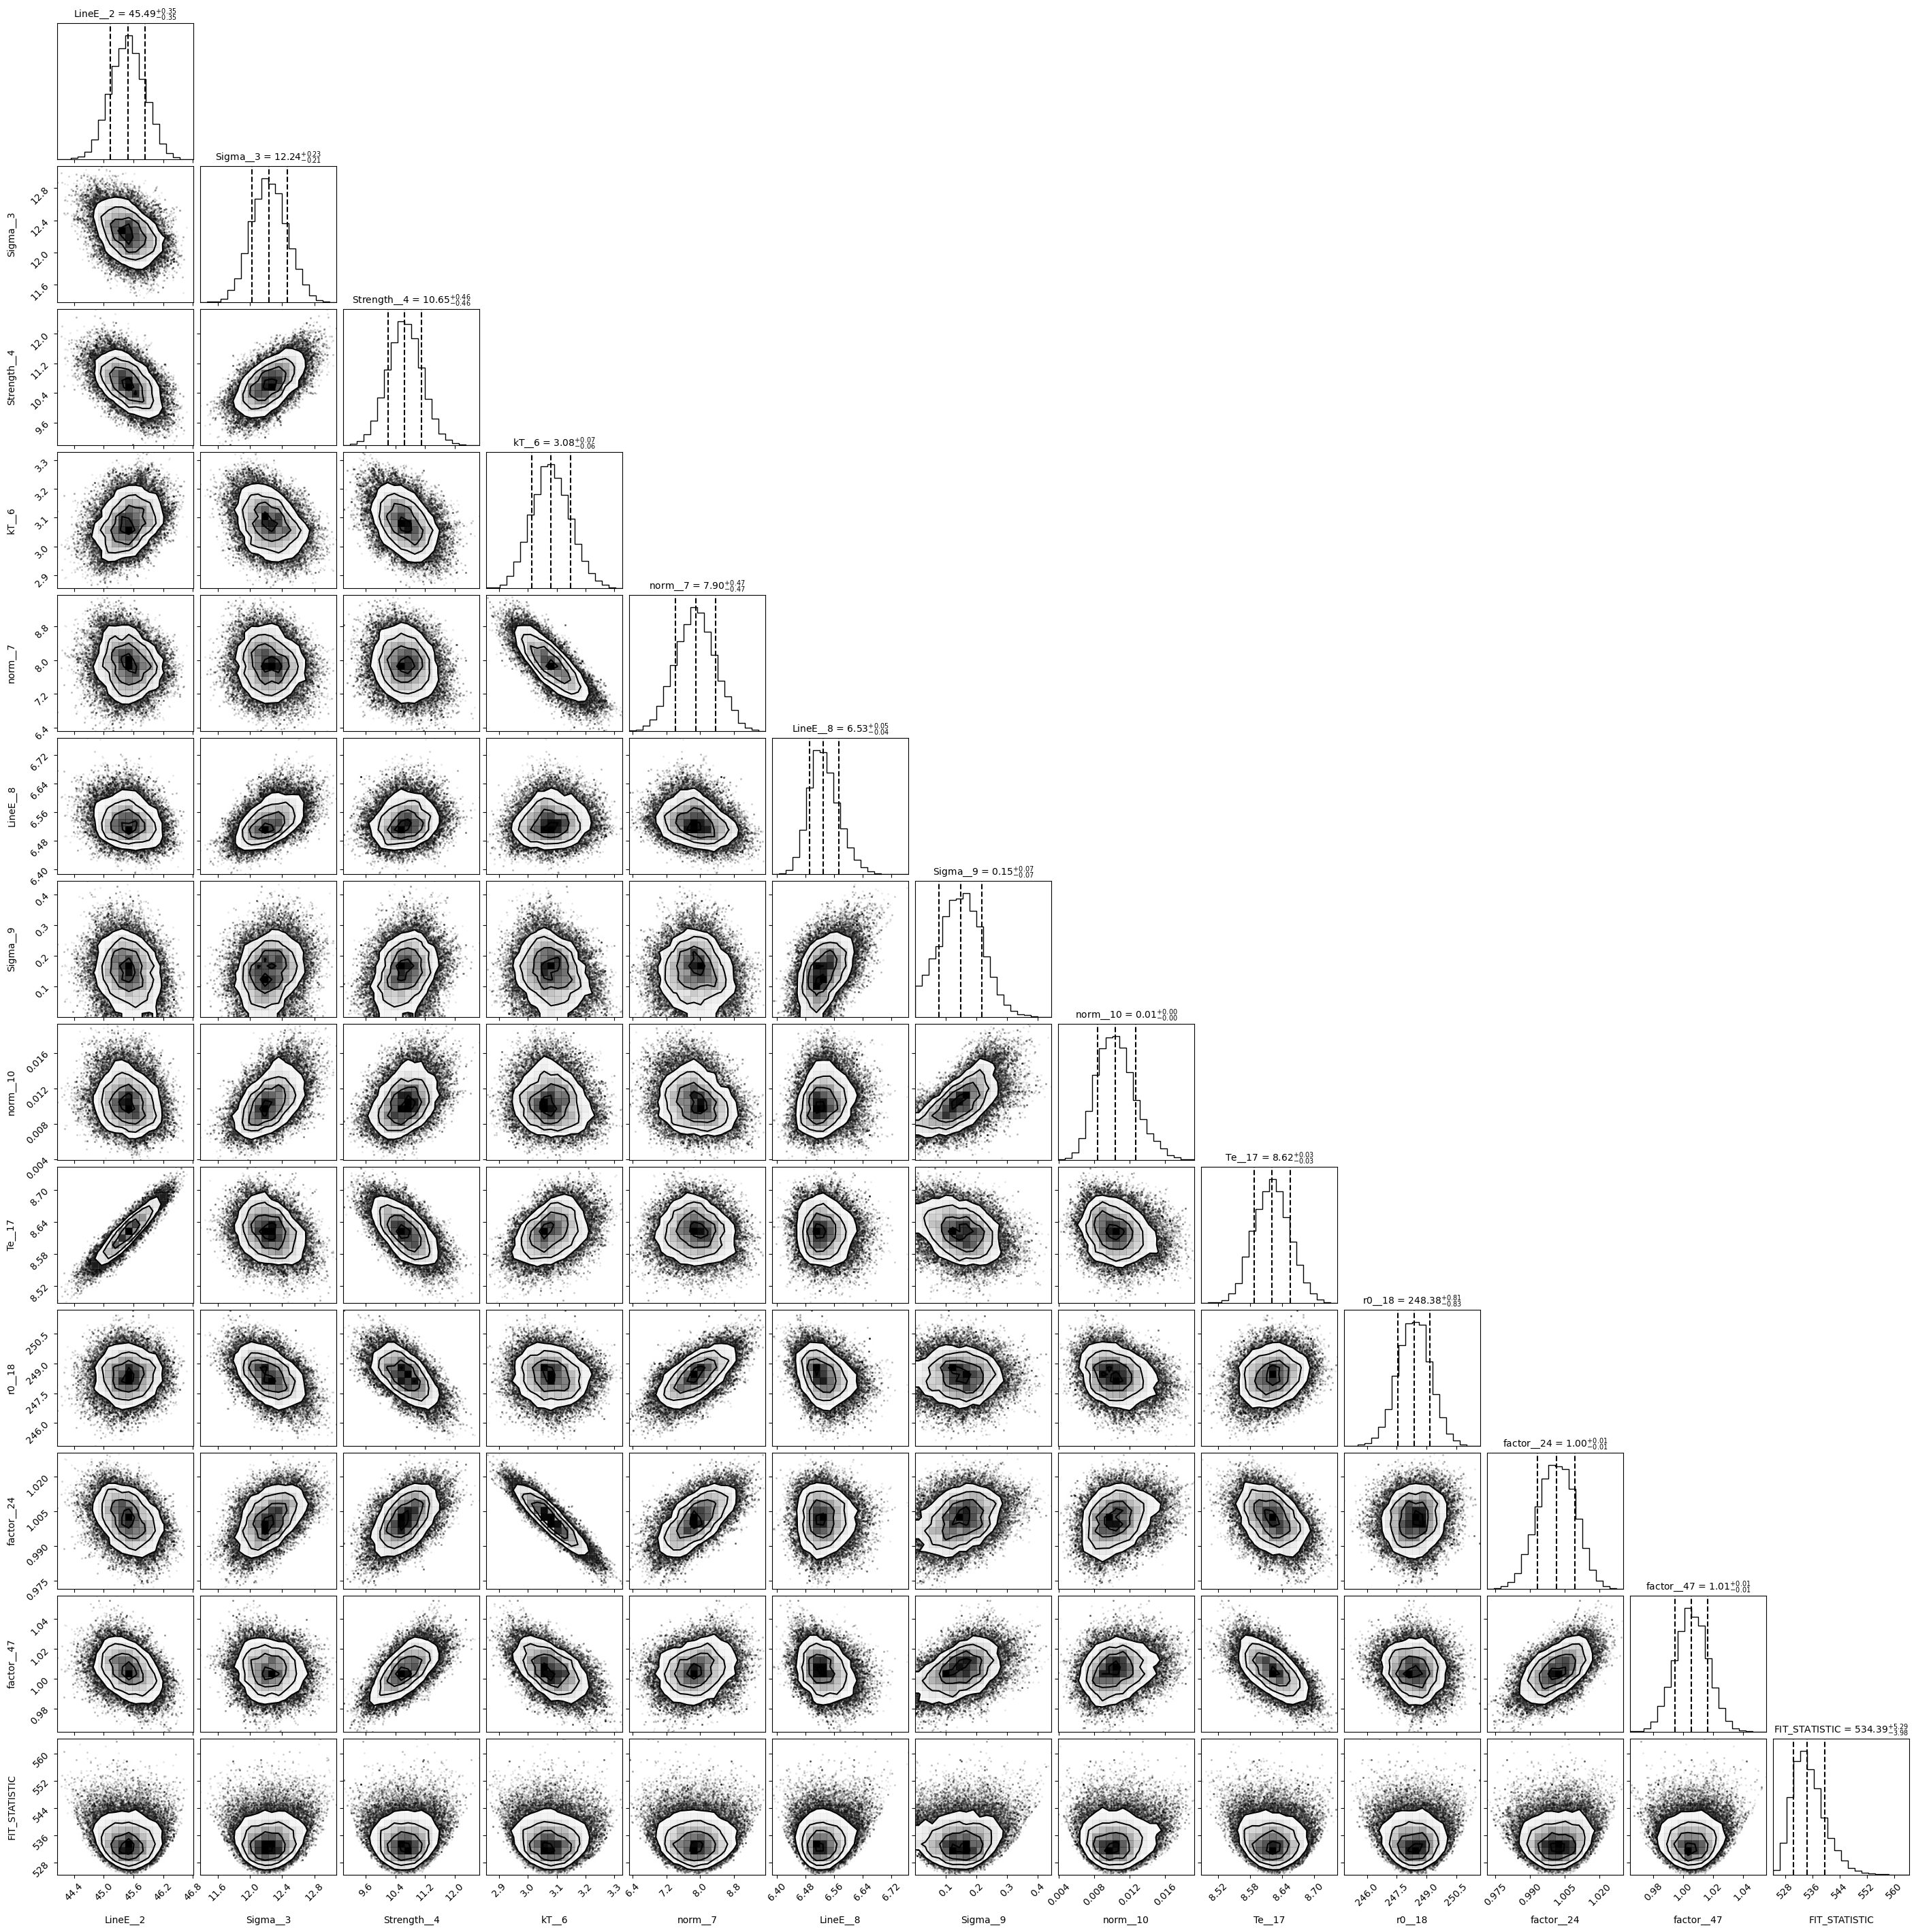

In [2]:
import corner
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits

# Define the path to the MCMC FITS file
#mcmc_file = "20201120_QPOphase/mcmc_0506.fits"
#mcmc_file = "/Volumes/WD_BLACK/Data/1A0535p262/HXMT/date_combine/20201120/mcmc_bw.fits"
path = "/Volumes/WD_BLACK/Data/1A0535p262/HXMT/HHT/20201208_QPOphase"
mcmc_file = f"{path}/mcmc.fits"
#mcmc_file1 = "20201120_QPOphase/mcmc_0001.fits"
try:
    # Read MCMC FITS file
    with fits.open(mcmc_file) as mcmc_fits:
        data_table = mcmc_fits[1].data
        names = data_table.columns.names
        # Read MCMC FITS file
    # with fits.open(mcmc_file1) as mcmc_fits1:
    #     data_table1 = mcmc_fits1[1].data
    #     names1 = data_table1.columns.names
    
    print("Parameter Names:", names)
    #names = ['LineE__3', 'Strength__5', 'LineE__6', 'Sigma__7', 'Strength__8', 'Gamma1__12', 'Ecut__13', 'Efold__14']
    #names = ['LineE__3', 'Strength__5', 'LineE__6', 'Sigma__7', 'Strength__8', 'norm__11', 'Gamma1__12', 'Ecut__13', 'Efold__14', 'norm__15', 'factor__16', 'factor__31', 'FIT_STATISTIC']
    # Convert FITS data to a NumPy array (excluding any non-numeric columns if needed)
    param_data = np.column_stack([data_table[name] for name in names])
    #param_data1 = np.column_stack([data_table1[name] for name in names])
    
    # Define labels for the corner plot (formatting LaTeX for better visualization)
    label_names = names  # Escaping underscores for LaTeX
    # label_names = [r'$E_{\rm cyc2}$ keV',r'$S_{\rm cyc2}$ keV',
    #                r'$E_{\rm cyc1}$ keV',r'$\sigma_{\rm cyc1}$ keV',r'$S_{\rm cyc1}$ keV',
    #                r'$\Gamma$',r'$E_{\rm cut}$ keV', r'$E_{\rm fold}$ keV']
    
    
    # Generate the corner plot
    figure = corner.corner(
        param_data,
        labels=label_names,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 10}
    )
    # corner.corner(
    #     param_data1,
    #     labels=label_names,
    #     quantiles=[0.16, 0.5, 0.84],
    #     show_titles=True,
    #     title_kwargs={"fontsize": 10}
    # )
    
    # Show and optionally save the plot
    #plt.savefig("mcmc_corner_plot_bw.pdf")  # Uncomment to save as PDF
    plt.show()
    
except FileNotFoundError as e:
    print(f"Error: {e}")
except ValueError as ve:
    print(f"Data Mismatch Error: {ve}")
except Exception as e:
    print(f"An error occurred: {e}")

